## Credit Card Risk Assessment

In [ ]:
import pandas as pd
%pip install imbalanced-learn
%pip install shap

In [ ]:
credit_df=pd.read_csv('Credit_default_dataset.csv')
credit_df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'Credit_default_dataset.csv'

In [ ]:
#We don't need the ID column,so lets drop it.
credit_df = credit_df.drop(["ID"],axis=1)

In [ ]:
#changing the name of  pay_0 column to pay_1 to make the numbering correct
credit_df.rename(columns={'PAY_0':'PAY_1'}, inplace=True)

In [ ]:
credit_df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
#Removing Unwanted categorical levels as mentioned in data exploration
credit_df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


## Data Preprocessing Steps

In [ ]:
credit_df["EDUCATION"]=credit_df["EDUCATION"].map({0:4,1:1,2:2,3:3,4:4,5:4,6:4})
credit_df["MARRIAGE"]=credit_df["MARRIAGE"].map({0:3,1:1,2:2,3:3})

In [ ]:
# 1. Feature Engineering: Risk Ratios
# Credit Utilization (How much of their limit they are using)
for i in range(1, 7):
    # Adding a small epsilon (1e-6) to avoid division by zero
    credit_df[f'UTILIZATION_{i}'] = credit_df[f'BILL_AMT{i}'] / (credit_df['LIMIT_BAL'] + 1e-6)

# Payment to Bill Ratio (How much of the bill they actually paid)
for i in range(1, 7):
    # Mapping PAY_AMT1 to BILL_AMT2, PAY_AMT2 to BILL_AMT3, etc. based on the dataset logic
    bill_col = f'BILL_AMT{i+1}' if i < 6 else 'BILL_AMT6'
    credit_df[f'PAY_RATIO_{i}'] = credit_df[f'PAY_AMT{i}'] / (credit_df[bill_col] + 1e-6)

# Now define X and y with the new features BEFORE scaling
X = credit_df.drop(['default.payment.next.month'], axis=1)
y = credit_df['default.payment.next.month']

In [ ]:
# 2. Handling Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
import pandas as pd

# Check original distribution
print("Original class distribution:\n", y.value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Resampled class distribution:\n", y_resampled.value_counts())

# Now apply your StandardScaler to the resampled data
from sklearn.preprocessing import StandardScaler
scaling = StandardScaler()
X_scaled = scaling.fit_transform(X_resampled)

Original class distribution:
 default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
Resampled class distribution:
 default.payment.next.month
1    23364
0    23364
Name: count, dtype: int64


In [ ]:
## Hyper Parameter Optimization

params={
 "learning_rate"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30 ] ,
 "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15],
 "min_child_weight" : [ 1, 3, 5, 7 ],
 "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]

}

In [ ]:
## Hyperparameter optimization using RandomizedSearchCV
# 3a. Baseline Model (To prove the 0.65 starting point)
from sklearn.model_selection import cross_val_score
import xgboost

baseline_clf = xgboost.XGBClassifier(random_state=42)
# Notice we explicitly define the scoring metric here
baseline_score = cross_val_score(baseline_clf, X_scaled, y_resampled, cv=5, scoring='roc_auc')
print(f"Baseline ROC-AUC: {baseline_score.mean():.2f}")

# 3b. GridSearchCV (Replacing RandomizedSearchCV)
from sklearn.model_selection import GridSearchCV

# Note: GridSearch checks EVERY combination. Shrink the params slightly from your
# random search list so this doesn't take 5 hours to run.
params = {
 "learning_rate"    : [0.10, 0.25],
 "max_depth"        : [3, 5, 8],
 "min_child_weight" : [3, 7],
 "gamma"            : [0.1, 0.3],
 "colsample_bytree" : [0.4, 0.7]
}

classifier = xgboost.XGBClassifier(random_state=42)
grid_search = GridSearchCV(classifier, param_grid=params, scoring='roc_auc', n_jobs=-1, cv=5, verbose=3)

# Fit the grid search on the scaled, SMOTE data
grid_search.fit(X_scaled, y_resampled)

print("Best Parameters:", grid_search.best_params_)
print("Best Optimized ROC-AUC:", grid_search.best_score_)

Baseline ROC-AUC: 0.90
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0.3, 'learning_rate': 0.25, 'max_depth': 8, 'min_child_weight': 3}
Best Optimized ROC-AUC: 0.9046774677219339


In [ ]:
def timer(start_time=None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    elif start_time:
        thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
        tmin, tsec = divmod(temp_sec, 60)
        print('\n Time taken: %i hours %i minutes and %s seconds.' % (thour, tmin, round(tsec, 2)))

In [ ]:
classifier=xgboost.XGBClassifier()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search=RandomizedSearchCV(classifier,param_distributions=params,n_iter=5,scoring='roc_auc',n_jobs=-1,cv=5,verbose=3)

In [ ]:

from datetime import datetime
# Here we go
start_time = timer(None) # timing starts from this point for "start_time" variable
random_search.fit(X,y)
timer(start_time) # timing ends here for "start_time" variable

Fitting 5 folds for each of 5 candidates, totalling 25 fits

 Time taken: 0 hours 0 minutes and 30.98 seconds.


In [ ]:
random_search.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
random_search.best_params_

{'min_child_weight': 3,
 'max_depth': 5,
 'learning_rate': 0.1,
 'gamma': 0.1,
 'colsample_bytree': 0.4}

In [ ]:
classifier=xgboost.XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
       colsample_bytree=0.4, gamma=0.1, learning_rate=0.25,
       max_delta_step=0, max_depth=3, min_child_weight=7, missing=None,
       n_estimators=100, n_jobs=1, nthread=None,
       objective='binary:logistic', random_state=0, reg_alpha=0,
       reg_lambda=1, scale_pos_weight=1, seed=None, silent=True,
       subsample=1)

In [ ]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(classifier,X,y,cv=10)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:07:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 144, in __call__
    score = scorer(estimator, *args, **routed_params.get(name).score)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 472, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 572, in score
    return accuracy_score(y

In [ ]:
score

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [ ]:
score.mean()

np.float64(nan)

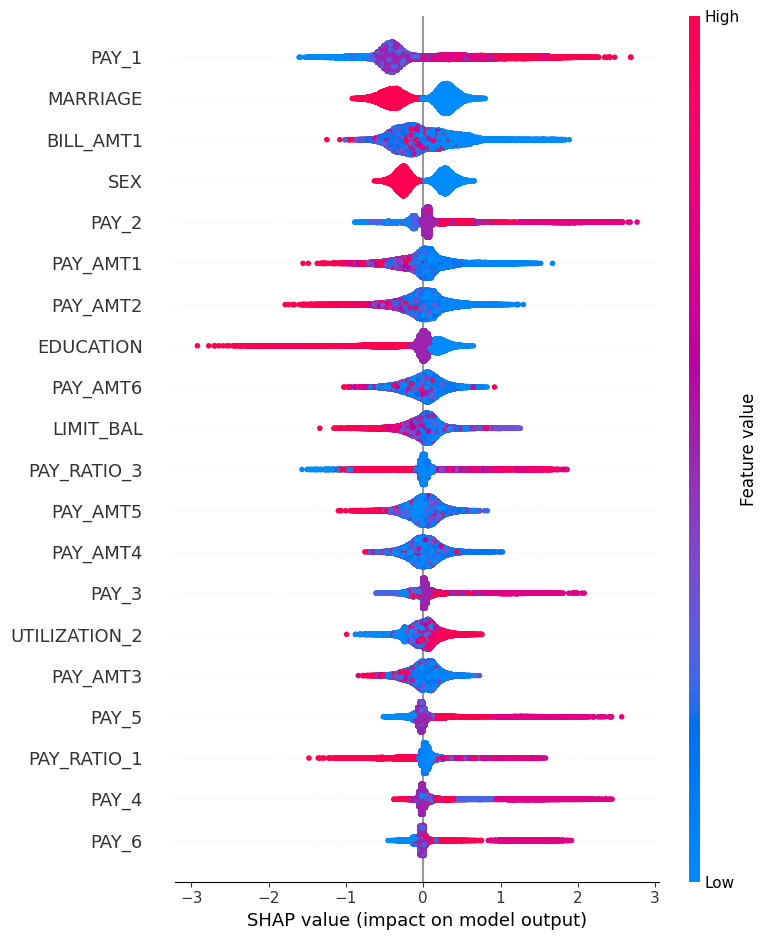

In [ ]:
# 4. SHAP Integration for Feature Attribution
import shap

# Train the final model with the best parameters from GridSearch
best_clf = grid_search.best_estimator_
# Best practice is to train on the data before extracting SHAP values
best_clf.fit(X_scaled, y_resampled)

# Initialize the TreeExplainer (optimized for tree-based models like XGBoost)
explainer = shap.TreeExplainer(best_clf)

# Calculate SHAP values (using a sample if the dataset is large to save time)
# We convert X_scaled back to a dataframe temporarily just so SHAP plots have the right column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
shap_values = explainer.shap_values(X_scaled_df)

# Generate a Summary Plot (Global interpretability)
shap.summary_plot(shap_values, X_scaled_df)

# Generate a Force Plot for the very first prediction (Local interpretability)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_scaled_df.iloc[0,:])